
 FIRST 5 ROWS
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             

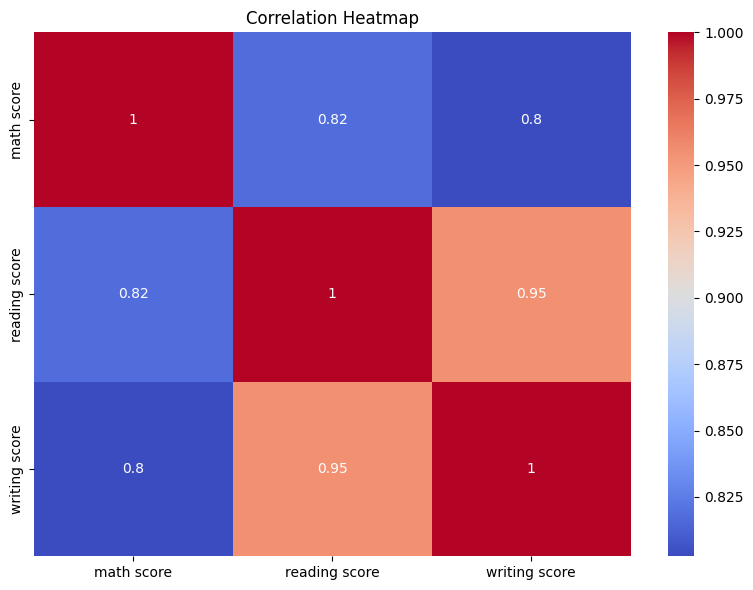

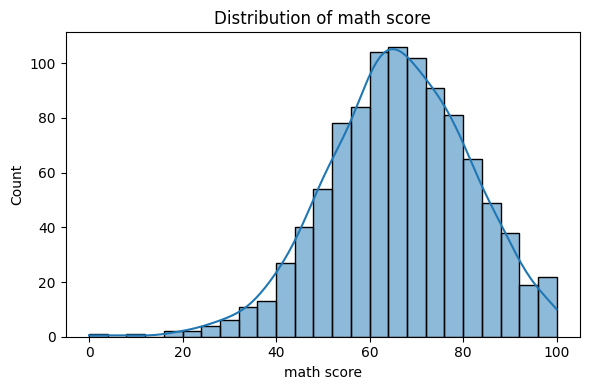

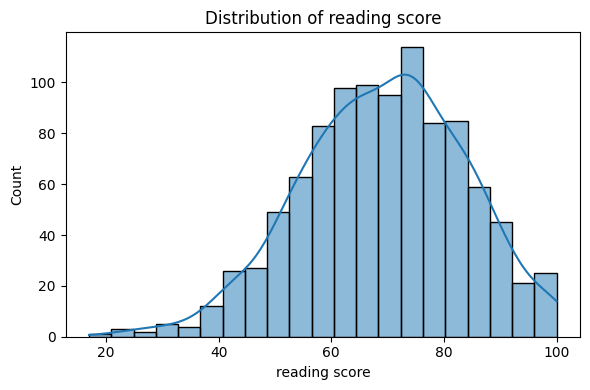

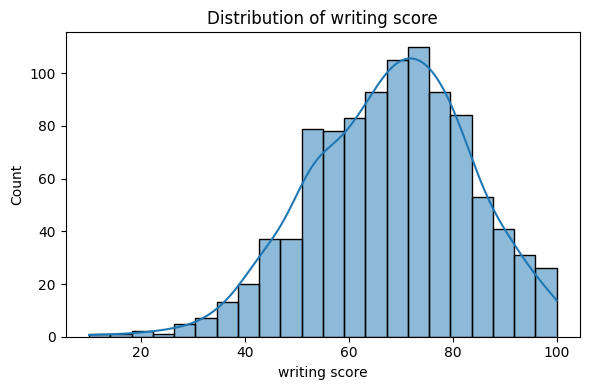

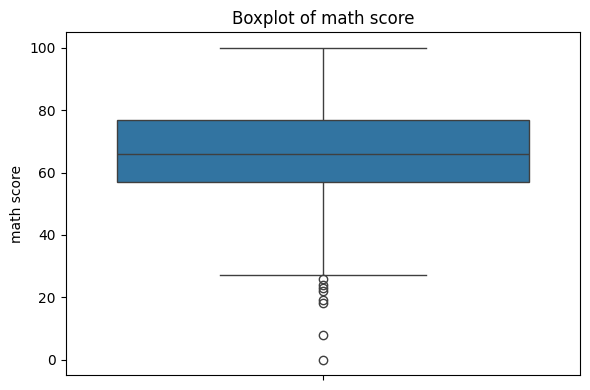

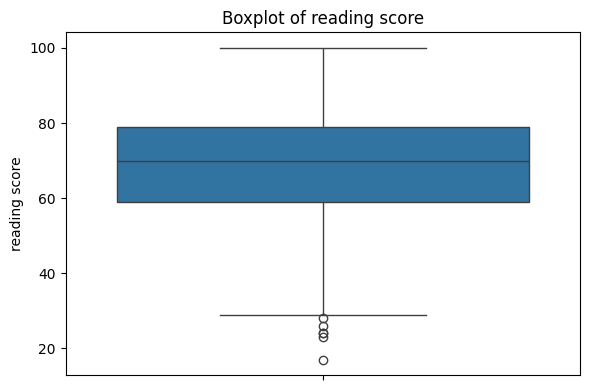

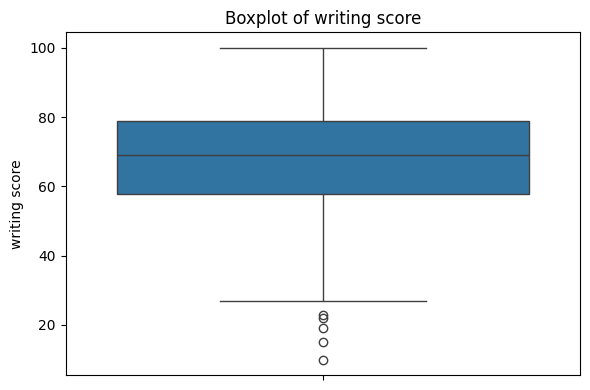


 GENDER-WISE AVERAGE SCORES
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


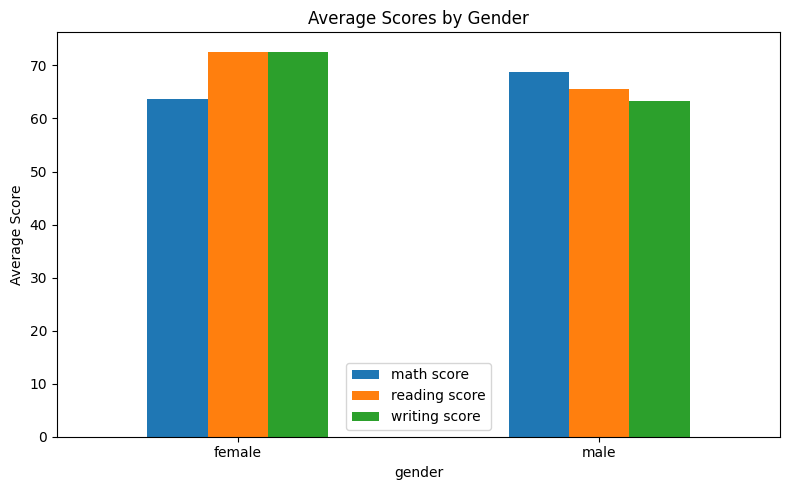


 LUNCH TYPE IMPACT
              math score  reading score  writing score
lunch                                                 
free/reduced       58.92          64.65          63.02
standard           70.03          71.65          70.82


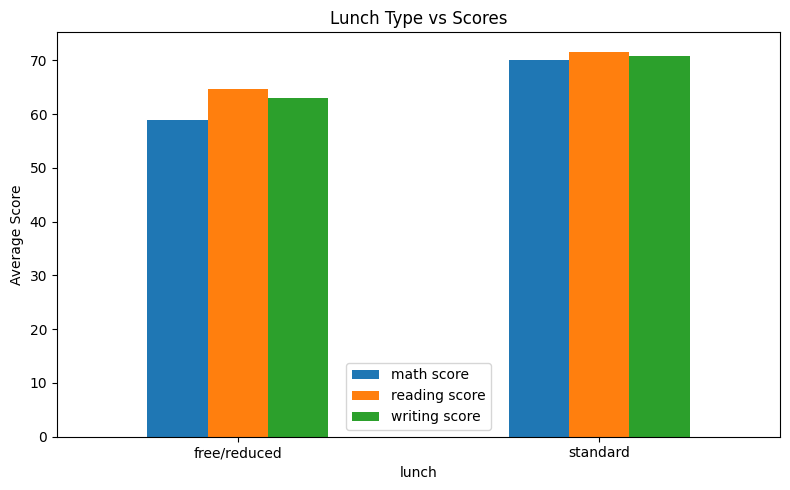


 PARENTAL EDUCATION IMPACT
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                       62.14          64.70          62.45
master's degree                   69.75          75.37          75.68
some college                      67.13          69.46          68.84
some high school                  63.50          66.94          64.89


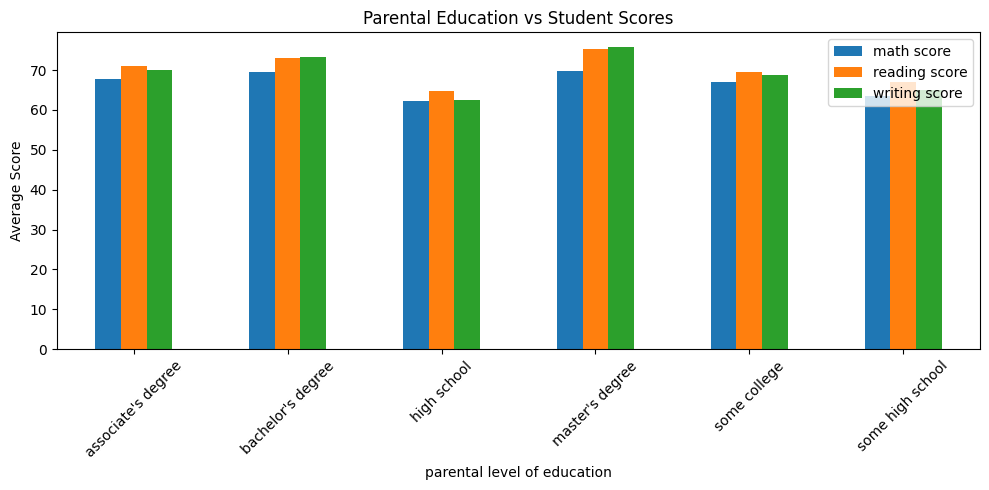


 TOP 10 STUDENTS
     gender  Total Score  Average Score
916    male          300     100.000000
962  female          300     100.000000
458  female          300     100.000000
114  female          299      99.666667
712  female          297      99.000000
179  female          297      99.000000
165  female          296      98.666667
625    male          296      98.666667
685  female          293      97.666667
903  female          293      97.666667


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option('display.max_columns', None)
# Load dataset
df = pd.read_csv("/content/archive (4).zip")
# 1. Basic Information
print("\n FIRST 5 ROWS")
print(df.head())
print("\n DATASET INFO")
print(df.info())
print("\n SHAPE OF DATASET")
print(df.shape)
print("\n COLUMN NAMES")
print(df.columns)
# 2. Missing Values Check
print("\n MISSING VALUES")
print(df.isnull().sum())
# 3. Statistical Summary
print("\n STATISTICAL SUMMARY")
print(df.describe().round(2))
# 4. Check Duplicates
print("\n DUPLICATE ROWS")
print(df.duplicated().sum())
# 5. Correlation Analysis
print("\n CORRELATION")
corr = df.select_dtypes(include=np.number).corr()
print(corr.round(2))
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
# 6. Distribution of Scores
score_cols = ['math score', 'reading score', 'writing score']
for col in score_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
# 7. Boxplots
for col in score_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()
# 8. Gender-wise Performance
gender_scores = df.groupby('gender')[score_cols].mean()
print("\n GENDER-WISE AVERAGE SCORES")
print(gender_scores.round(2))
gender_scores.plot(kind='bar', figsize=(8,5))
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 9. Lunch Type Impact
lunch_scores = df.groupby('lunch')[score_cols].mean()
print("\n LUNCH TYPE IMPACT")
print(lunch_scores.round(2))
lunch_scores.plot(kind='bar', figsize=(8,5))
plt.title("Lunch Type vs Scores")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 10. Parental Education Impact
education_scores = df.groupby('parental level of education')[score_cols].mean()
print("\n PARENTAL EDUCATION IMPACT")
print(education_scores.round(2))
education_scores.plot(kind='bar', figsize=(10,5))
plt.title("Parental Education vs Student Scores")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 11. Create Total and Average Score
df['Total Score'] = (df['math score'] +df['reading score'] +df['writing score'])
df['Average Score'] = df['Total Score'] / 3
print("\n TOP 10 STUDENTS")
print(df[['gender', 'Total Score', 'Average Score']].sort_values(by='Total Score', ascending=False).head(10))